In [6]:
# !pip install qiskit-ibm-runtime

In [43]:
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict

from qiskit.quantum_info import SparsePauliOp
from qiskit.circuit.library import QAOAAnsatz
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit import QuantumCircuit
from qiskit.visualization import plot_histogram

from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime import Session, EstimatorV2 as Estimator
from qiskit_ibm_runtime import SamplerV2 as Sampler

In [70]:
circuit = QuantumCircuit(4, 4)

circuit.h(0)
circuit.cx(0, 1)
circuit.cx(0, 2)
circuit.cx(0, 3)
circuit.barrier()

circuit.measure([0, 1, 2, 3], [0, 1, 2, 3])

In [71]:
circuit.draw()

┌───┐                ░ ┌─┐         
q_0: ┤ H ├──■────■────■───░─┤M├─────────
     └───┘┌─┴─┐  │    │   ░ └╥┘┌─┐      
q_1: ─────┤ X ├──┼────┼───░──╫─┤M├──────
          └───┘┌─┴─┐  │   ░  ║ └╥┘┌─┐   
q_2: ──────────┤ X ├──┼───░──╫──╫─┤M├───
               └───┘┌─┴─┐ ░  ║  ║ └╥┘┌─┐
q_3: ───────────────┤ X ├─░──╫──╫──╫─┤M├
                    └───┘ ░  ║  ║  ║ └╥┘
c: 4/════════════════════════╩══╩══╩══╩═
                             0  1  2  3

In [72]:
circuit.parameters

ParameterView([])

In [73]:
service = QiskitRuntimeService(
    channel='ibm_quantum_platform',
    instance='open-instance',
    token='GxJLCChZSqPxJu02Qleqk3ayzZQy46Av8IsrHWYRyzaq'
)
backend = service.least_busy(
    operational=True, simulator=False, min_num_qubits=127
)
print(backend)

qiskit_runtime_service._discover_account:WARNING:2026-05-18 23:54:46,087: Loading account with the given token. A saved account will not be used.


<IBMBackend('ibm_kingston')>


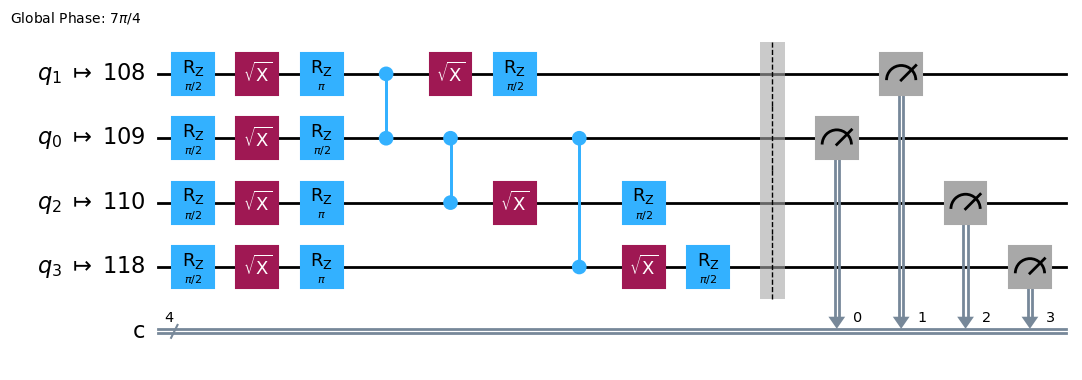

In [74]:
pm = generate_preset_pass_manager(optimization_level=3, backend=backend)

candidate_circuit = pm.run(circuit)
candidate_circuit.draw("mpl", fold=False, idle_wires=False)

# using Estimator

In [86]:
observables_labels = ["ZZZZ"]
observables = [SparsePauliOp(label) for label in observables_labels]

isa_observables = [obsv.apply_layout(candidate_circuit.layout) for obsv in observables]

In [87]:
estimator = Estimator(mode=backend)

In [88]:
job = estimator.run([(candidate_circuit, isa_observables)])

In [89]:
print(f">>> Job ID: {job.job_id()}")
print(f">>> Job Status: {job.status()}")

>>> Job ID: d85ljjntjchs73brfhd0
>>> Job Status: QUEUED


In [ ]:
result = job.result()
print(f">>> {result}")
print(f"  > Expectation value: {result[0].data.evs}")
print(f"  > Metadata: {result[0].metadata}")

In [ ]:
job_result = job.result()
pub_result = job.result()[0]

In [ ]:
values = pub_result.data.evs

errors = pub_result.data.stds

# plotting graph
plt.plot(observables_labels, values, "-o")
plt.xlabel("Observables")
plt.ylabel("Values")
plt.show()

# using Sampler

In [ ]:
sampler_real = Sampler(mode=backend)

In [ ]:
job_counts_sampler = sampler_real.run([(candidate_circuit)], shots=1024)

In [ ]:
print(f">>> Job ID: {job_counts_sampler.job_id()}")
print(f">>> Job Status: {job_counts_sampler.status()}")

In [ ]:
result_sampler = job_counts_sampler.result()
result_sampler

In [ ]:
counts_real = result_sampler[0].data.c.get_counts()

In [ ]:
plot_histogram(counts_real)